# Autoencoder (AE) Models

## Introduction

Intrusion detection in IoT networks presents unique challenges due to the heterogeneity of devices, communication protocols, and traffic patterns. Traditional supervised classifiers rely on labeled examples of both normal and attack traffic activity. However, in many real-world cybersecurity settings, obtaining representative attack samples is difficult because new attack patterns continually emerge.

Autoencoders provide a useful alternative by learning the structure of normal network behavior without requiring labeled attack traffic data. Instead of directly predicting class labels, an autoencoder learns to reconstruct input observations that follow the normal traffic distribution. When the model encounters anomalous or malicious traffic patterns that deviate from this learned structure, the reconstruction error tends to increase. This property allows **reconstruction error to serve as an anomaly score for intrusion detection**.

In this section, autoencoders are trained exclusively on normal network traffic from the RT-IoT 2022 dataset. **Observations that produce large reconstruction errors during inference are classified as anomalous** and interpreted as potential attacks.

### Model Formulation
An autoencoder is a neural network designed to learn a compressed representation of input data and reconstruct the original input from this representation. It consists of two components:

- Encoder: maps the input feature vector into a lower-dimensional latent representation.
- Decoder: reconstructs the original input from the latent representation.

$$
x \in \mathbb{R}^d
$$

where $d$ represents the number of features in the dataset.

The encoder transforms the input into a latent representation $z$:

$$
z = f_{\theta}(x)
$$

where $f_{\theta}(\cdot)$ denotes the encoder network parameterized by weights $\theta$.

The decoder reconstructs the input:

$$
\hat{x} = g_{\phi}(z)
$$

where $g_{\phi}(\cdot)$ represents the decoder network parameterized by weights $\phi$.

Combining both operations gives the full autoencoder mapping:

$$
\hat{x} = g_{\phi}(f_{\theta}(x))
$$

The encoder compresses the information in the input into a lower-dimensional representation, while the decoder attempts to reconstruct the original feature vector from that representation.

### Training Objective

The autoencoder is trained using the **mean squared reconstruction error** over the training dataset consisting only of normal traffic observations.

For a dataset with $N$ samples, the optimization objective is

$$
\min_{\theta,\phi} \frac{1}{N}\sum_{i=1}^{N} \|x_i - \hat{x}_i\|^2
$$

where

$$
\hat{x}_i = g_{\phi}(f_{\theta}(x_i))
$$

This objective encourages the model to learn latent representations that accurately capture the structure of normal traffic. Because the model is only exposed to benign samples during training, it becomes specialized at reconstructing patterns consistent with normal network behavior.

### Reconstruction Error as an Anomaly Score

After training, the reconstruction error for a new observation is computed as

$$
s(x) = \|x - \hat{x}\|^2
$$

where $s(x)$ represents the anomaly score for observation $x$.

Intuitively:

- **Normal traffic** should produce small reconstruction errors because the model has learned similar patterns during training.
- **Attack traffic** often produces larger reconstruction errors because the feature patterns differ from those observed during training.

Therefore, reconstruction error serves as a continuous anomaly score used to detect suspicious traffic.

### Threshold Selection via Validation F1 Score:

To convert anomaly scores into binary predictions, a threshold $\tau$ must be selected such that

$$
\hat{y} =
\begin{cases}
1 & \text{if } s(x) > \tau \\
0 & \text{otherwise}
\end{cases}
$$

where

- $\hat{y}=1$ indicates an attack
- $\hat{y}=0$ indicates normal traffic.

The threshold $\tau$ is selected using the validation dataset by maximizing the **F1 score**, defined as

$$
F1 = \frac{2(\text{Precision} \cdot \text{Recall})}{\text{Precision} + \text{Recall}}
$$

where

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

and

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

with $TP$, $FP$, and $FN$ denoting true positives, false positives, and false negatives respectively.

The optimal threshold is chosen as

$$
\tau^* = \arg\max_{\tau} F1(\tau)
$$

### Why F1 Score is Used

The RT-IoT dataset exhibits a strong imbalance between attack and normal traffic, with attack observations comprising a large portion of the dataset. In such settings, metrics such as **accuracy can be misleading** because a model may achieve high accuracy while failing to detect rare or minority classes effectively.

The F1 score balances precision and recall, making it particularly suitable for intrusion detection tasks:

- **Precision** penalizes false alarms by measuring the proportion of predicted attacks that are actually malicious.
- **Recall** measures the ability of the model to correctly detect attacks.

By maximizing the F1 score during threshold selection, the model achieves a balance between detecting malicious activity and minimizing false positives, which is critical for practical intrusion detection systems.

In [1]:
#| output: false

import sys
from pathlib import Path
# Set to root for src load
root = Path.cwd()
while root != root.parent and not (root / "src").exists():
    root = root.parent

if not (root / "src").exists():
    raise FileNotFoundError("Could not find 'src' folder above current working directory.")

sys.path.insert(0, str(root))
print("Project root:", root)

Project root: c:\Users\joetn\Real-Time_IoT_2022_Quantized_Auto_Encoder


In [2]:
from src.preprocessing import stratified_train_val_test_split
from src.autoencoder import (
    AEConfig,
    BaselineAutoencoder,
    train_autoencoder,
    reconstruction_error,
    tune_threshold_max_f1,
    convert_to_fp16,
    convert_to_uint8_dynamic
)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


In [3]:
# Path from notebooks/ → project root → data/processed
processed_dir = Path("../data/processed")

# Load datasets from EDA
X_all = pd.read_csv(processed_dir / "X_all.csv")
y_bin = pd.read_csv(processed_dir / "y_bin.csv")["target"]

In [4]:
# Set plt plotting configs
plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "legend.title_fontsize": 9,
    "legend.frameon": True,
    "legend.borderpad": 0.3
})

## Baseline AE Model

### Data Preparation

To evaluate the autoencoder models, we first imported the processed but unscaled feature matrix produced during the EDA stage. This matrix consists of both numeric features and one-hot encoded categorical variables, resulting in a fully numeric design matrix suitable for neural network training. The corresponding binary target labels were also imported, where normal traffic is represented by $y=0$ and attack traffic by $y=1$.

The dataset was then partitioned using a stratified train, validation, and test split in order to preserve the original class proportions across all subsets. Importantly, **no downsampling was performed** during this step. Maintaining the full dataset ensures that the training procedure has access to the largest possible set of normal/benign observations, which is critical for learning a robust representation of normal network behavior. The resulting split proportions are summarized in @tbl-rtiot-ae-train-val-test-split.

Because the autoencoder is trained in an unsupervised anomaly detection setting, the model should only learn from benign examples. Therefore, after the stratified split was performed, **all attack observations were removed from the training set**, leaving only normal traffic for model fitting. The validation and test sets retain both normal and attack observations so that model performance can be evaluated in a realistic detection scenario.

In [5]:
#| label: tbl-rtiot-ae-train-val-test-split
#| tbl-cap: "Stratified train, validation, and test split preserving the original class distribution. Autoencoder models are trained using only normal traffic (y=0) from the training set, while validation and test sets retain both normal and attack observations for anomaly detection evaluation."
(X_train, y_train), (X_val, y_val), (X_test, y_test) = stratified_train_val_test_split(
    X_all,
    y_bin,
    train_size=0.70,
    val_size=0.15,
    test_size=0.15,
    downsample_train=1,
    random_state=42
)

# Keep only normal traffic for autoencoder training
X_train_norm = X_train[y_train == 0]
y_train_norm = y_train[y_train == 0]

dist_df = pd.DataFrame({
    "split": ["train_all", "train_normal", "val", "test"],
    "rows": [len(y_train), len(y_train_norm), len(y_val), len(y_test)],
    "attack_rate": [
        y_train.mean(),
        y_train_norm.mean(),
        y_val.mean(),
        y_test.mean()
    ]
})

display(dist_df)

,split,rows,attack_rate
0,train_all,86181,0.898411
1,train_normal,8755,0.000000
2,val,18468,0.898419
3,test,18468,0.898419


### Feature Scaling and Tensor Conversion

Neural networks are sensitive to the scale of input features. To ensure stable training, we applied feature standardization using the training data. Specifically, a scaler was fitted on the normal training observations and then applied to the validation and test features using the same parameters. This prevents information leakage from the evaluation sets into the training process. After scaling, the feature matrices were converted into **PyTorch tensors with 32-bit floating point precision (float32)**, which is the standard datatype used for neural network training in PyTorch.

In [6]:
# Fit scaler only on normal training data
scaler = StandardScaler()
X_train_norm_s = scaler.fit_transform(X_train_norm)

# Transform all splits using the same scaler
X_train_s = scaler.transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

In [7]:
#| output: false

# Convert to PyTorch tensors
X_train_norm_t = torch.tensor(X_train_norm_s, dtype=torch.float32)
X_val_t = torch.tensor(X_val_s, dtype=torch.float32)
X_test_t = torch.tensor(X_test_s, dtype=torch.float32)

# Confirm input dimension
input_dim = X_train_norm_t.shape[1]
print("Input dimension:", input_dim)

Input dimension: 103


### Baseline Autoencoder Architecture

The baseline autoencoder architecture was designed as a **fully connected symmetric encoder–decoder network**, with the configuration summarized in @tbl-rtiot-ae-configs. The encoder compresses the input feature vector into a lower-dimensional latent representation, while the decoder attempts to reconstruct the original input from this compressed representation. This architecture introduces a bottleneck latent space, forcing the model to learn compact representations of normal traffic patterns. If an observation differs substantially from the learned distribution, the decoder will struggle to reconstruct it accurately, resulting in a larger reconstruction error that can signal anomalous behavior.

In [8]:
#| label: tbl-rtiot-ae-configs
#| tbl-cap: "Baseline autoencoder architecture configuration. The encoder compresses the 103-dimensional input feature space through hidden layers of 64 and 32 units into a 16-dimensional latent representation, while the decoder mirrors this structure to reconstruct the original input. This gradual compression introduces a bottleneck that encourages the model to learn compact representations of normal network traffic patterns."

# Conservative baseline architecture for gradual compression of feature space
ae_cfg = AEConfig(
    input_dim=input_dim,
    hidden_dim_1=64,
    hidden_dim_2=32,
    latent_dim=16,
    dropout=0.0
)

display(pd.DataFrame([ae_cfg.__dict__]))

,input_dim,hidden_dim_1,hidden_dim_2,latent_dim,dropout
0,103,64,32,16,0.0


In [9]:
#| output: false

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [10]:
#| output: false

baseline_ae = BaselineAutoencoder(
    input_dim=ae_cfg.input_dim,
    hidden_dim_1=ae_cfg.hidden_dim_1,
    hidden_dim_2=ae_cfg.hidden_dim_2,
    latent_dim=ae_cfg.latent_dim,
    dropout=ae_cfg.dropout,
).to(device)

baseline_ae

BaselineAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=103, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=32, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=64, out_features=103, bias=True)
  )
)

### Training Procedure

The normal training observations were wrapped into a **mini-batch data loader**, enabling the model to process subsets of data during each optimization step. Mini-batch training improves computational efficiency and stabilizes gradient updates compared to full-batch optimization. The autoencoder was trained using the mean squared error (MSE) reconstruction loss as explained in the introduction. This loss function directly aligns with the goal of autoencoder training: minimizing the reconstruction error of normal traffic patterns.

Model parameters were optimized using the **Adam optimizer**, which is a widely used adaptive gradient method that combines the advantages of momentum-based optimization and adaptive learning rates. Adam is particularly well suited for neural networks because it can efficiently handle noisy gradient estimates and typically converges faster than standard stochastic gradient descent. The model was trained for **30 epochs**, during which the average training reconstruction error steadily decreased, indicating that the network successfully learned to reproduce normal traffic behavior. The evolution of the training loss over epochs is shown in @fig-rtiot-ae-baseline-training-loss.

In [11]:
# Wrap normal-only training data in a TensorDataset
train_dataset = TensorDataset(X_train_norm_t)

# Mini-batch loader for training (gradient descent)
train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

# Loss function: reconstruction error during training
criterion = nn.MSELoss()

# Adam Optimizer
optimizer = torch.optim.Adam(baseline_ae.parameters(), lr=1e-3)

In [12]:
#| output: false

train_losses = train_autoencoder(
    model=baseline_ae,
    train_loader=train_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    num_epochs=30,
)

Epoch [01/30] - train_loss: 0.808241
Epoch [02/30] - train_loss: 0.372727
Epoch [03/30] - train_loss: 0.303177
Epoch [04/30] - train_loss: 0.226535
Epoch [05/30] - train_loss: 0.177004
Epoch [06/30] - train_loss: 0.158041
Epoch [07/30] - train_loss: 0.138431
Epoch [08/30] - train_loss: 0.116796
Epoch [09/30] - train_loss: 0.098538
Epoch [10/30] - train_loss: 0.085137
Epoch [11/30] - train_loss: 0.075688
Epoch [12/30] - train_loss: 0.068682
Epoch [13/30] - train_loss: 0.063605
Epoch [14/30] - train_loss: 0.059231
Epoch [15/30] - train_loss: 0.056877
Epoch [16/30] - train_loss: 0.051731
Epoch [17/30] - train_loss: 0.048805
Epoch [18/30] - train_loss: 0.046242
Epoch [19/30] - train_loss: 0.044403
Epoch [20/30] - train_loss: 0.042410
Epoch [21/30] - train_loss: 0.040238
Epoch [22/30] - train_loss: 0.039464
Epoch [23/30] - train_loss: 0.037374
Epoch [24/30] - train_loss: 0.036412
Epoch [25/30] - train_loss: 0.034276
Epoch [26/30] - train_loss: 0.033422
Epoch [27/30] - train_loss: 0.032158
E

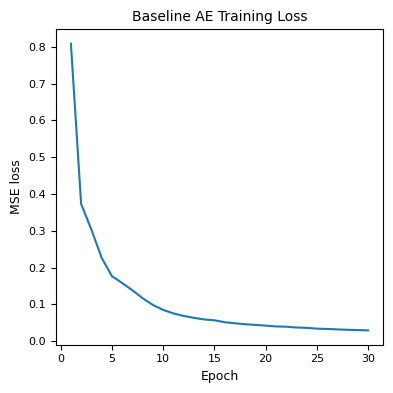

In [13]:
#| label: fig-rtiot-ae-baseline-training-loss
#| fig-cap: "Training mean squared reconstruction loss for the baseline autoencoder across 30 epochs using normal traffic only. The decreasing loss indicates that the model progressively improves its ability to reconstruct normal network behavior, which forms the basis for anomaly detection via reconstruction error."

import matplotlib.pyplot as plt

plt.figure(figsize=(4, 4))
plt.plot(range(1, len(train_losses) + 1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Baseline AE Training Loss")
plt.tight_layout()
plt.show()

In [14]:
#| output: false

# Sanity check
train_norm_err = reconstruction_error(baseline_ae, X_train_norm_t, device)
pd.Series(train_norm_err).describe()

count    8755.000000
mean        0.029193
std         0.147980
min         0.000774
25%         0.002522
50%         0.004432
75%         0.008236
max         4.976237
dtype: float64

### Reconstruction Error and Threshold Selection

After training, the autoencoder was applied to the validation and test sets to compute the **reconstruction error** for each observation. Because the model has only seen normal traffic during training, benign observations are expected to produce small reconstruction errors, while malicious traffic typically produces larger errors.

To convert reconstruction errors into binary predictions, a decision threshold was selected using the validation set. Specifically, a range of candidate thresholds was evaluated and the value that **maximized the validation F1 score** was chosen. The F1 score balances precision and recall, making it particularly suitable for imbalanced intrusion detection datatsets where both missed attacks and excessive false alarms are undesirable.

In [15]:
#| output: false

# Compute reconstruction error for val & test for tuning
val_err = reconstruction_error(baseline_ae, X_val_t, device)
test_err = reconstruction_error(baseline_ae, X_test_t, device)

best_thr, best_val_f1 = tune_threshold_max_f1(
    y_true=y_val,
    scores=val_err,
    n_grid=200
)

pd.DataFrame([{
    "threshold": best_thr,
    "val_f1": best_val_f1
}])

,threshold,val_f1
0,0.05757,0.99528


### Baseline Model Performance

Using the optimal threshold derived from the validation set, the baseline autoencoder was evaluated on the held-out test set. Performance metrics including accuracy, precision, recall, F1 score, ROC-AUC, and PR-AUC are reported in @tbl-rtiot-ae-baseline-training-metrics. These metrics collectively assess the model’s ability to correctly identify attack traffic while minimizing false positives.

The resulting confusion matrix, shown in @tbl-rtiot-ae-baseline-confusion, provides a detailed breakdown of classification outcomes. The matrix illustrates how many attack samples were correctly detected, how many benign samples were mistakenly flagged as anomalies, and how often the model produced correct normal predictions.

Overall, the baseline autoencoder demonstrates **strong anomaly detection capability**, indicating that reconstruction error effectively separates normal and malicious traffic patterns in the dataset.

In [16]:
#| label: tbl-rtiot-ae-baseline-training-metrics
#| tbl-cap: "Baseline autoencoder anomaly detection performance. The anomaly threshold was selected on the validation set by maximizing the F1 score, and final evaluation metrics (accuracy, precision, recall, F1, ROC-AUC, and PR-AUC) are reported on the held-out test set."


y_val_pred = (val_err > best_thr).astype(int)
y_test_pred = (test_err > best_thr).astype(int)

baseline_results = pd.DataFrame([{
    "threshold": best_thr,
    "n_features": X_all.shape[1],
    "val_f1": best_val_f1,
    "test_accuracy": accuracy_score(y_test, y_test_pred),
    "test_precision": precision_score(y_test, y_test_pred, zero_division=0),
    "test_recall": recall_score(y_test, y_test_pred, zero_division=0),
    "test_f1": f1_score(y_test, y_test_pred, zero_division=0),
    "test_roc_auc": roc_auc_score(y_test, test_err),
    "test_pr_auc": average_precision_score(y_test, test_err)
}])

display(baseline_results.style.hide(axis="index"))

threshold,n_features,val_f1,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc
0.057570,103,0.995280,0.992203,0.993697,0.997649,0.995669,0.995642,0.999394


In [17]:
#| label: tbl-rtiot-ae-baseline-confusion
#| tbl-cap: "Confusion matrix for the baseline autoencoder evaluated on the test set using the threshold selected from validation F1 maximization. The matrix summarizes correct and incorrect classifications of normal and attack traffic, illustrating the model’s ability to detect malicious flows while maintaining a relatively low false-positive rate for benign traffic."


cm = confusion_matrix(y_test, y_test_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Normal", "Actual Attack"],
    columns=["Pred Normal", "Pred Attack"]
)

display(cm_df)

,Pred Normal,Pred Attack
Actual Normal,1771,105
Actual Attack,39,16553


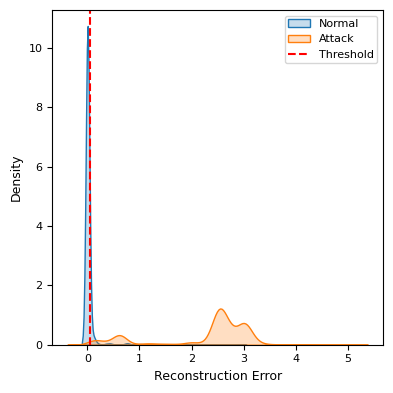

In [18]:
#| output: false

err_df = pd.DataFrame({
    "error": test_err,
    "label": y_test
})

plt.figure(figsize=(4,4))

sns.kdeplot(
    data=err_df[err_df.label == 0],
    x="error",
    label="Normal",
    fill=True,
)

sns.kdeplot(
    data=err_df[err_df.label == 1],
    x="error",
    label="Attack",
    fill=True,
)

plt.axvline(best_thr, color="red", linestyle="--", label="Threshold")

plt.xlabel("Reconstruction Error")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

## Quantized Autoencoder Variants (QAE-f16 and QAE-u8)

After establishing the baseline autoencoder, we investigated whether similar anomaly detection performance could be maintained under reduced numerical precision, which is particularly relevant for deployment on resource-constrained IoT and edge devices. Two quantized variants were evaluated: a **half-precision autoencoder (QAE-f16)** and an **8-bit dynamically quantized autoencoder (QAE-u8)**. Rather than retraining new models, both variants were obtained by converting the trained baseline autoencoder to lower-precision representations and repeating the inference and evaluation pipeline.

The first variant, QAE-f16, converts the model parameters from standard 32-bit floating point (FP32) precision to 16-bit floating point (FP16). **Half precision reduces the memory footprint of the model by approximately 50%**, while typically preserving most of the numerical fidelity required for neural network inference. Because the model architecture and learned weights remain unchanged aside from precision, the FP16 model can be evaluated using the same inference pipeline as the baseline autoencoder.

The second variant, QAE-u8, applies dynamic 8-bit quantization to the linear layers of the trained autoencoder. In this setting, model weights are stored internally as 8-bit integers (INT8), and activations are dynamically quantized during inference. Dynamic quantization significantly reduces model memory requirements and can improve CPU inference efficiency, particularly on edge hardware devices. Compared with FP32 weights, INT8 quantization **reduces the storage required per parameter by approximately 75%**, making it an attractive option for lightweight deployment.

Once the baseline model was converted into the QAE-f16 and QAE-u8 variants, we repeated the same inference procedure used for the baseline autoencoder. Reconstruction errors were computed for the validation and test sets, and a decision threshold was selected by maximizing the validation **F1 score** using the same threshold search procedure from the previous section. The resulting thresholds, along with the final evaluation metrics, are summarized in @tbl-rtiot-ae-model-comparison.

One notable observation is that the QAE-u8 model produced a slightly shifted reconstruction error threshold compared with the baseline and QAE-f16 models. However, despite this shift in threshold magnitude, the overall detection performance remained remarkably stable. Across all three models, metrics such as *ccuracy, precision, recall, F1 score, ROC-AUC, and PR-AUC exhibit only minimal deviations, indicating that the **quantized representations preserve the essential structure learned by the original autoencoder**.

The comparative performance of the three models is visualized in @fig-rtiot-ae-model-test-metrics-comparison, which shows that both quantized variants achieve nearly identical test-set performance to the baseline autoencoder. These results suggest that reduced-precision autoencoders can maintain strong anomaly detection capability even when model weights are stored with significantly lower numerical precision.

In [19]:
#| output: false

# Convert baseline model to half precision (float16)
qae_f16 = convert_to_fp16(baseline_ae)

# Convert input tensors to float16
X_val_t_f16 = X_val_t.half()
X_test_t_f16 = X_test_t.half()

# Compute reconstruction error
val_err_f16 = reconstruction_error(qae_f16, X_val_t_f16, device)
test_err_f16 = reconstruction_error(qae_f16, X_test_t_f16, device)

# Tune threshold to max F1
best_thr_f16, best_val_f1_f16 = tune_threshold_max_f1(
    y_true=y_val,
    scores=val_err_f16
)

# Evaluate on test set
y_test_pred_f16 = (test_err_f16 > best_thr_f16).astype(int)

results_f16 = pd.DataFrame([{
    "model": "QAE-f16",
    "n_features": X_all.shape[1],
    "threshold": best_thr_f16,
    "val_f1": best_val_f1_f16,
    "test_accuracy": accuracy_score(y_test, y_test_pred_f16),
    "test_precision": precision_score(y_test, y_test_pred_f16, zero_division=0),
    "test_recall": recall_score(y_test, y_test_pred_f16, zero_division=0),
    "test_f1": f1_score(y_test, y_test_pred_f16, zero_division=0),
    "test_roc_auc": roc_auc_score(y_test, test_err_f16),
    "test_pr_auc": average_precision_score(y_test, test_err_f16)
}])

display(results_f16)

,model,n_features,threshold,val_f1,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc
0,QAE-f16,103,0.057547,0.99528,0.992203,0.993697,0.997649,0.995669,0.995642,0.999395


In [20]:
#| output: false

# Convert baseline model to 8-bit dynamic quantized model
qae_u8 = convert_to_uint8_dynamic(baseline_ae)

# Set to CPU for dynamic quantized models
device_u8 = torch.device("cpu")

# Compute reconstruction error
val_err_u8 = reconstruction_error(qae_u8, X_val_t.float(), device_u8)
test_err_u8 = reconstruction_error(qae_u8, X_test_t.float(), device_u8)

# Tune threshold to max F1
best_thr_u8, best_val_f1_u8 = tune_threshold_max_f1(
    y_true=y_val,
    scores=val_err_u8,
    n_grid=200
)

# Evaluate on test set
y_test_pred_u8 = (test_err_u8 > best_thr_u8).astype(int)

results_u8 = pd.DataFrame([{
    "model": "QAE-u8",
    "n_features": X_all.shape[1],
    "threshold": best_thr_u8,
    "val_f1": best_val_f1_u8,
    "test_accuracy": accuracy_score(y_test, y_test_pred_u8),
    "test_precision": precision_score(y_test, y_test_pred_u8, zero_division=0),
    "test_recall": recall_score(y_test, y_test_pred_u8, zero_division=0),
    "test_f1": f1_score(y_test, y_test_pred_u8, zero_division=0),
    "test_roc_auc": roc_auc_score(y_test, test_err_u8),
    "test_pr_auc": average_precision_score(y_test, test_err_u8)
}])

display(results_u8)


,model,n_features,threshold,val_f1,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc
0,QAE-u8,103,0.104821,0.994739,0.992365,0.993698,0.99783,0.99576,0.995534,0.999385


In [21]:
#| label: tbl-rtiot-ae-model-comparison
#| tbl-cap: "Comparison of baseline and quantized autoencoder models. Metrics include validation F1 used for threshold selection and test-set performance metrics (accuracy, precision, recall, F1, ROC-AUC, and PR-AUC). Despite reduced numerical precision, both QAE-f16 and QAE-u8 achieve performance nearly identical to the baseline autoencoder, with only minor deviations in reconstruction threshold."

comparison_df = pd.concat([
    baseline_results.assign(model="Baseline AE"),
    results_f16,
    results_u8
], ignore_index=True)

cols = ["model"] + [c for c in comparison_df.columns if c != "model"]
comparison_df = comparison_df[cols]

display(
    comparison_df.style
    .format("{:.3e}", subset=comparison_df.select_dtypes(include="number").columns)
    .hide(axis="index")
)

model,threshold,n_features,val_f1,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc
Baseline AE,5.757e-02,1.030e+02,9.953e-01,9.922e-01,9.937e-01,9.976e-01,9.957e-01,9.956e-01,9.994e-01
QAE-f16,5.755e-02,1.030e+02,9.953e-01,9.922e-01,9.937e-01,9.976e-01,9.957e-01,9.956e-01,9.994e-01
QAE-u8,1.048e-01,1.030e+02,9.947e-01,9.924e-01,9.937e-01,9.978e-01,9.958e-01,9.955e-01,9.994e-01


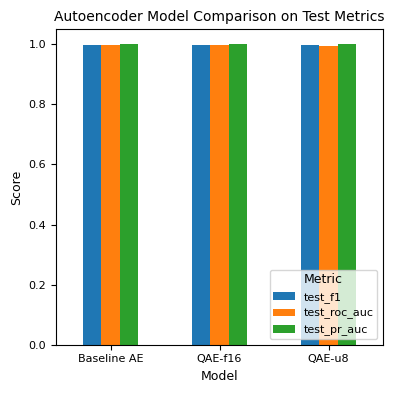

In [22]:
#| label: fig-rtiot-ae-model-test-metrics-comparison
#| fig-cap: "Comparison of baseline and quantized autoencoder models on key test-set anomaly detection metrics. All three models achieved strong performance."

plot_df = comparison_df[["model", "test_f1", "test_roc_auc", "test_pr_auc"]].copy()
plot_df = plot_df.set_index("model")

ax = plot_df.plot(kind="bar", figsize=(4, 4))
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_title("Autoencoder Model Comparison on Test Metrics")
plt.xticks(rotation=0)
plt.legend(title="Metric", loc="lower right")
plt.tight_layout()
plt.show()

From a deployment perspective, the most compelling advantage of quantization is the reduction in **model storage requirements**. As illustrated in @fig-rtiot-ae-model-size-comparison, decreasing the parameter precision from 32-bit (baseline) to 16-bit (QAE-f16) and 8-bit (QAE-u8) progressively lowers the number of bits required to store each weight. This reduction directly translates to smaller model artifacts and potentially faster inference on CPU-bound edge devices. The ability of **QAE-u8 to retain near-baseline detection performance while dramatically reducing precision requirements highlights its practical value for IoT environments**, where computational resources and memory are often limited.

Finally, the reconstruction error distributions for normal and attack traffic across all three models are shown in @fig-rtiot-ae-error-distributions-by-model. These distributions demonstrate that the separation between benign and malicious traffic remains clearly visible even after quantization. This stability explains why the detection metrics remain largely unchanged despite the reduction in numerical precision.

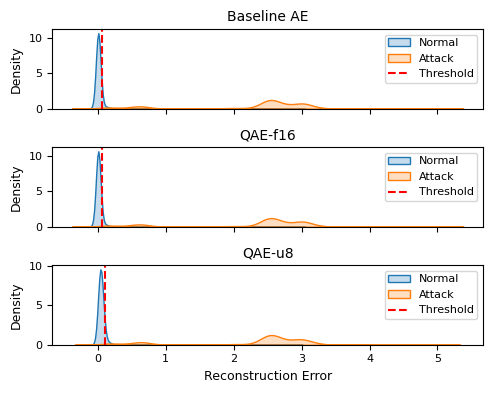

In [23]:
#| label: fig-rtiot-ae-error-distributions-by-model
#| fig-cap: "Reconstruction error distributions for normal and attack traffic across the baseline, QAE-f16, and QAE-u8 models. All models preserve strong separation between normal and attack traffic with insignificant shifts in error magnitude and threshold."

fig, axes = plt.subplots(3, 1, figsize=(5, 4), sharex=True)

model_plots = [
    ("Baseline AE", test_err, best_thr),
    ("QAE-f16", test_err_f16, best_thr_f16),
    ("QAE-u8", test_err_u8, best_thr_u8),
]

for ax, (title, errs, thr) in zip(axes, model_plots):
    err_df = pd.DataFrame({
        "error": errs,
        "label": y_test
    })

    sns.kdeplot(
        data=err_df[err_df["label"] == 0],
        x="error",
        fill=True,
        label="Normal",
        ax=ax
    )
    sns.kdeplot(
        data=err_df[err_df["label"] == 1],
        x="error",
        fill=True,
        label="Attack",
        ax=ax
    )
    ax.axvline(thr, color="red", linestyle="--", label="Threshold")
    ax.set_title(title)
    ax.set_ylabel("Density")
    ax.legend()

axes[-1].set_xlabel("Reconstruction Error")
plt.tight_layout()
plt.show()

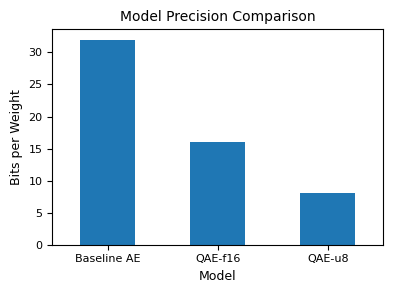

In [24]:
#| label: fig-rtiot-ae-model-size-comparison
#| fig-cap: "Relative parameter precision of baseline and quantized autoencoder models."

precision_df = pd.DataFrame({
    "model": ["Baseline AE", "QAE-f16", "QAE-u8"],
    "bits_per_weight": [32, 16, 8]
})

ax = precision_df.plot(
    kind="bar",
    x="model",
    y="bits_per_weight",
    legend=False,
    figsize=(4,3)
)

ax.set_ylabel("Bits per Weight")
ax.set_xlabel("Model")
ax.set_title("Model Precision Comparison")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The results in @tbl-rtiot-ae-model-comparison-final indicate that all evaluated models achieve very strong classification performance on the RT-IoT 2022 dataset. Given the **class imbalance between normal and attack traffic**, greater emphasis should be placed on **ROC-AUC and PR-AUC**, which provide a more reliable assessment of detection performance across decision thresholds. All models achieve extremely high ROC-AUC values (≈0.996), indicating excellent separability between normal and malicious traffic. The logistic regression models also achieve **very high PR-AUC values (≈0.9996)**, while the autoencoder models achieve **PR-AUC values near 0.9995**, reflecting strong precision–recall tradeoffs for the attack class. These results suggest that **the dataset contains highly separable patterns between normal and attack traffic**. The baseline logistic regression model already performs exceptionally well, achieving a test ROC-AUC of **0.996055**, a PR-AUC of **0.999898**, and an F1 score of **0.997197**, demonstrating that a simple linear decision boundary is capable of capturing most of the discriminative structure in the feature space. Feature selection using lasso and stepwise selection maintained similarly high ROC-AUC and PR-AUC performance while using only **23 and 9 features respectively**, indicating that a **reduced feature subset can retain most predictive information while improving model simplicity**.

The autoencoder-based models also achieve competitive performance. The baseline autoencoder yields a test ROC-AUC of **0.996167** and PR-AUC of **0.999533**, slightly lower in accuracy than the logistic regression models but still highly effective for anomaly detection. The quantized autoencoder variants (**QAE-f16** and **QAE-u8**) show nearly identical ROC-AUC and PR-AUC performance to the baseline autoencoder, with minimal degradation despite reduced numerical precision. This suggests that **quantization can substantially reduce model complexity and memory requirements while preserving detection capability**. Overall, these results demonstrate that while classical supervised models such as logistic regression provide strong predictive baselines, **quantized autoencoders offer a promising alternative for anomaly detection in resource-constrained IoT environments**, achieving comparable detection performance with potentially more efficient deployment characteristics.

In [25]:
#| label: tbl-rtiot-ae-model-comparison-final
#| tbl-cap: "Performance comparison of logistic regression and autoencoder-based models on the RT-IoT2022 dataset."

lr_results = pd.read_csv("../data/artifacts/lr_model_comparison.csv")
full_model_comparison = pd.concat(
    [lr_results, comparison_df],
    ignore_index=True
)

display(full_model_comparison)

,model,n_features,threshold,val_f1,test_roc_auc,test_pr_auc,test_accuracy,test_precision,test_recall,test_f1
0,baseline_lr,103,0.070000,0.996806,0.999055,0.999898,0.994964,0.997527,0.996866,0.997197
1,lasso_lr,23,0.060000,0.996836,0.996772,0.999587,0.994477,0.997706,0.996143,0.996924
2,stepwise_lr,9,0.050000,0.996625,0.996560,0.999626,0.994423,0.997466,0.996324,0.996894
3,Baseline AE,103,0.057570,0.995280,0.995642,0.999394,0.992203,0.993697,0.997649,0.995669
4,QAE-f16,103,0.057547,0.995280,0.995642,0.999395,0.992203,0.993697,0.997649,0.995669
5,QAE-u8,103,0.104821,0.994739,0.995534,0.999385,0.992365,0.993698,0.997830,0.995760


In [26]:
# Save metrics to artifacts
artifact_dir = Path("../data/artifacts")
artifact_dir.mkdir(parents=True, exist_ok=True)

pd.DataFrame(full_model_comparison).to_csv(artifact_dir / "full_model_comparison.csv", index=False)